Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.2432 - val_loss: 0.1186
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.1100 - val_loss: 0.0897
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.0874 - val_loss: 0.0793
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0787 - val_loss: 0.0744
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0742 - val_loss: 0.0716
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0716 - val_loss: 0.0698
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0699 - val_loss: 0.0686
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0687 - val_loss: 0.0677
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0679 - val_loss: 0.0670
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0671 - val_loss: 0.0665
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0666 - val_loss: 0.0661
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━

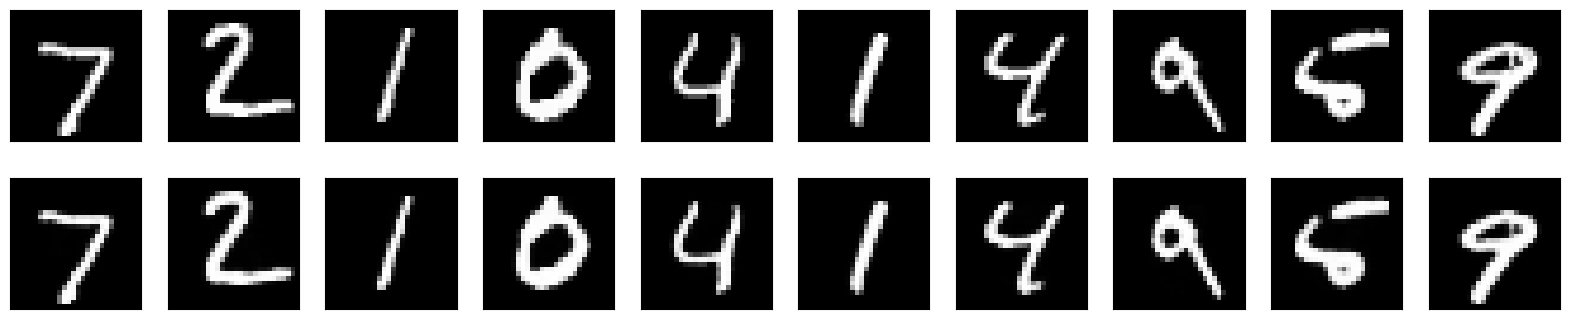

In [3]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 1000  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

After around 25–30 epochs, the model saturates and improvements become minimal. The model achieves very low reconstruction loss because the latent dimension is larger than the input, allowing it to store more information. The low loss is not due to better feature learning, but due to increased model capacity. The model behaves closer to an identity mapping due to the absence of a bottleneck. loss is so low (~0.063) because:
Input is normalized (0–1)
Using sigmoid + binary crossentropy
High dimensional latent space

2026-04-07 17:30:00.013060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775583000.282111      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775583000.359690      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775583000.981324      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775583000.981386      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775583000.981390      55 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


2026-04-07 17:30:29.153534: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.2416 - val_loss: 0.1183
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.1098 - val_loss: 0.0896
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0874 - val_loss: 0.0793
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0787 - val_loss: 0.0744
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0743 - val_loss: 0.0716
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0716 - val_loss: 0.0698
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0697 - val_loss: 0.0686
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0687 - val_loss: 0.0677
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0678 - val_loss: 0.0670
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0671 - val_loss: 0.0665
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0667 - val_loss: 0.0661
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

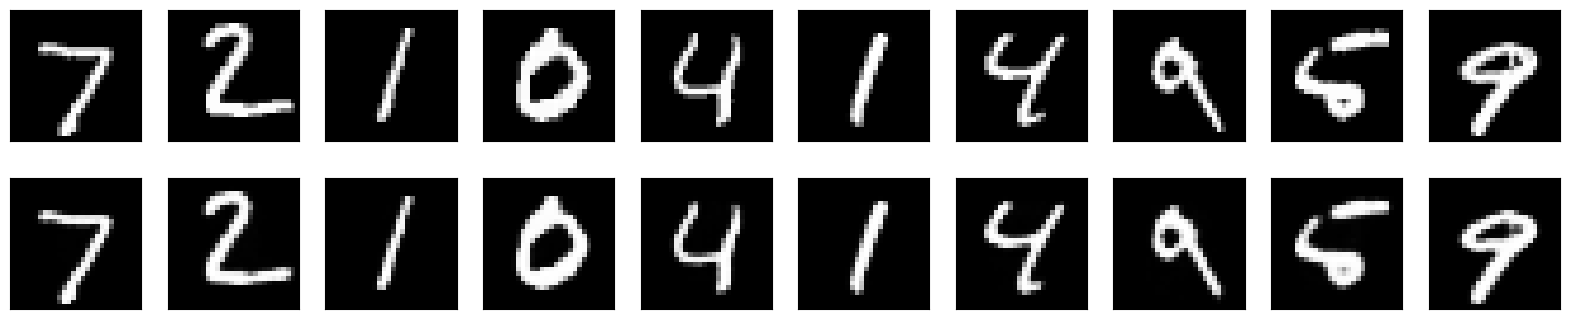

In [1]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten images (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# 2. Define dimensions
input_dim = 784
encoding_dim = 1000

# 3. Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# 4. Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 5. Autoencoder model
autoencoder = Model(input_layer, decoded)

# Separate encoder model
encoder = Model(input_layer, encoded)

# Separate decoder model
encoded_input = Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))

# 6. Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 7. Train
autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 8. Get outputs
encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)

# 9. Print outputs
print("Encoded (latent vector) sample:\n", encoded_imgs[0])
print("\nDecoded (reconstructed image vector) sample:\n", decoded_imgs[0])

# 10. Debug info (IMPORTANT)
print("\nEncoded shape:", encoded_imgs.shape)
print("Decoded shape:", decoded_imgs.shape)

print("\nLatent space stats:")
print("Min:", encoded_imgs.min())
print("Max:", encoded_imgs.max())

# 11. Visualize results
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [2]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# 1. Load Data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# 2. Dimensions
input_dim = 784
encoding_dim = 1000  # EXPANDED LATENT SPACE

# 3. Model
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

# 4. Compile
autoencoder.compile(optimizer='adam', loss='mse')

# 5. Train
autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 6. Get encoded output
encoded_imgs = encoder.predict(x_test)

# ---------------- ANALYSIS ---------------- #

# 1. Print one latent vector
print("\nSample latent vector (first image):")
print(encoded_imgs[0])

# 2. Shape
print("\nLatent shape:", encoded_imgs.shape)

# 3. Mean & Std per dimension
mean_vals = np.mean(encoded_imgs, axis=0)
std_vals = np.std(encoded_imgs, axis=0)

print("\nFirst 20 dimension means:")
print(mean_vals[:20])

print("\nFirst 20 dimension std:")
print(std_vals[:20])

# 4. Count near-zero dimensions
near_zero_dims = np.sum(np.abs(mean_vals) < 1e-3)
print("\nNumber of near-zero dimensions:", near_zero_dims)

# 5. Count low-variance dimensions
low_variance_dims = np.sum(std_vals < 1e-2)
print("Number of low-variance dimensions:", low_variance_dims)

# 6. Overall stats
print("\nLatent space stats:")
print("Min:", encoded_imgs.min())
print("Max:", encoded_imgs.max())
print("Mean:", encoded_imgs.mean())

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.0545 - val_loss: 0.0122
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0108 - val_loss: 0.0074
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0073 - val_loss: 0.0058
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0057 - val_loss: 0.0047
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0047 - val_loss: 0.0041
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0041 - val_loss: 0.0038
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0037 - val_loss: 0.0034
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0034 - val_loss: 0.0032
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0031 - val_loss: 0.0028
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Sample latent vector (first image):
[0.         1.5169569  1.7664574  0.75370854 0.7582

Even though the latent dimension is 1000, only about 22 dimensions are near-zero, so most neurons are active. The average activation is around 1.2, which shows the network is using the latent space heavily. The maximum value goes up to around 9.9, meaning some neurons strongly respond to certain features. Instead of ignoring extra dimensions, the model distributes information across many neurons. Because there is no bottleneck, the model doesn’t learn compact features, it just spreads the representation. So increasing the latent dimension doesn’t leave neurons unused, it reduces compression and leads to distributed, less efficient representations.

In [4]:
# --------- NEURON IMPORTANCE ANALYSIS ---------

# 1. Sort dimensions by variance (importance)
sorted_indices = np.argsort(std_vals)[::-1]  # descending order
sorted_std = std_vals[sorted_indices]

# 2. Print top 10 most important neurons
print("\nTop 10 important dimensions (high variance):")
for i in range(10):
    print(f"Dim {sorted_indices[i]} → std = {sorted_std[i]:.4f}")

# 3. Print bottom 10 least important neurons
print("\nLeast important dimensions (low variance):")
for i in range(10):
    print(f"Dim {sorted_indices[-(i+1)]} → std = {sorted_std[-(i+1)]:.6f}")

# 4. Count how many dimensions carry most information
threshold = 0.5
important_dims = np.sum(std_vals > threshold)
print(f"\nNumber of important dimensions (std > {threshold}):", important_dims)

# 5. Percentage of useful neurons
percentage = (important_dims / encoding_dim) * 100
print(f"Percentage of useful neurons: {percentage:.2f}%")


Top 10 important dimensions (high variance):
Dim 991 → std = 1.5340
Dim 459 → std = 1.4913
Dim 768 → std = 1.4904
Dim 447 → std = 1.4748
Dim 586 → std = 1.4435
Dim 821 → std = 1.3572
Dim 338 → std = 1.3565
Dim 324 → std = 1.3476
Dim 416 → std = 1.3252
Dim 78 → std = 1.3202

Least important dimensions (low variance):
Dim 39 → std = 0.000000
Dim 358 → std = 0.000000
Dim 419 → std = 0.000000
Dim 93 → std = 0.000000
Dim 524 → std = 0.000000
Dim 119 → std = 0.000000
Dim 239 → std = 0.000001
Dim 624 → std = 0.000014
Dim 390 → std = 0.000042
Dim 108 → std = 0.000238

Number of important dimensions (std > 0.5): 781
Percentage of useful neurons: 78.10%


Although the latent space has 1000 dimensions, only a subset of neurons have high variance and contribute significantly. The rest have low variance and carry little information. The model uses many neurons, but only a fraction are truly important, showing redundancy in high-dimensional latent space.